In [63]:
!pip install pyod

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from pyod.models.ecod import ECOD
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print(f"GPU available: {torch.cuda.is_available()}")

GPU available: True


In [64]:
from google.colab import drive
drive.mount('/content/drive')

aml_dataset = pd.read_csv('/content/drive/MyDrive/aml_anomaly_detection/HI-Small_Trans.csv')
print(aml_dataset.shape)
aml_dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5078345, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [65]:
print(aml_dataset.dtypes)
print(aml_dataset.isnull().sum())

Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


In [66]:
dupe_accounts = aml_dataset.groupby('Account')['From Bank'].nunique()
print(f"Accounts appearing under more than one bank: {(dupe_accounts > 1).sum()}")

aml_dataset['sender_id'] = aml_dataset['From Bank'].astype(str) + '_' + aml_dataset['Account'].astype(str)
aml_dataset['receiver_id'] = aml_dataset['To Bank'].astype(str) + '_' + aml_dataset['Account.1'].astype(str)


Accounts appearing under more than one bank: 4


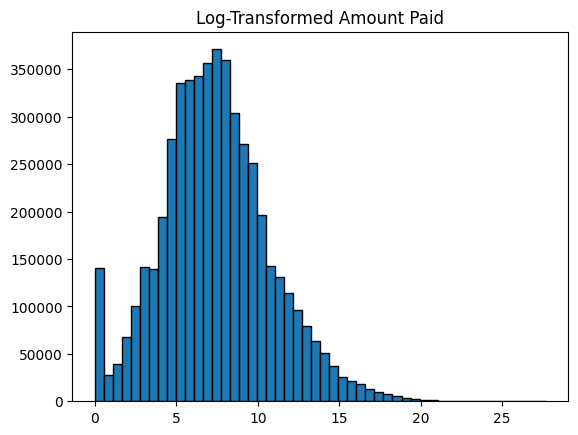

In [67]:
plt.hist(np.log1p(aml_dataset['Amount Paid']), bins=50, edgecolor='black')
plt.title('Log-Transformed Amount Paid')
plt.show()

In [68]:
print(aml_dataset['Payment Format'].value_counts())
print(aml_dataset['Receiving Currency'].value_counts())

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64
Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148151
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64


# Exploratory Data Analysis

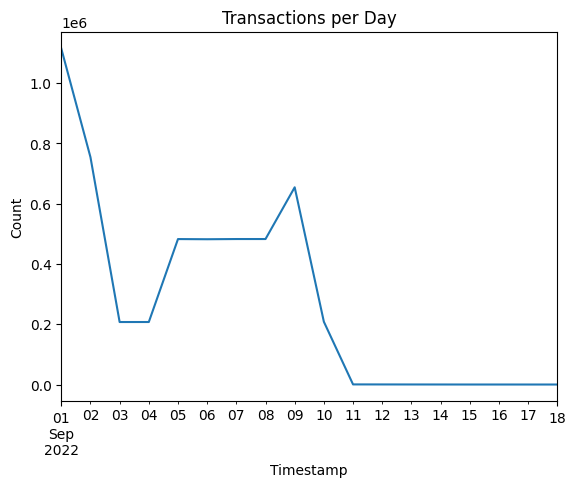

In [69]:
aml_dataset['Timestamp'] = pd.to_datetime(aml_dataset['Timestamp'])
aml_dataset.set_index('Timestamp').resample('D').size().plot()
plt.title('Transactions per Day')
plt.ylabel('Count')
plt.show()

In [70]:
daily_counts = aml_dataset.set_index('Timestamp').resample('D').size()
print(daily_counts)
print(f"\nTotal days with data: {(daily_counts > 0).sum()}")
print(f"Date range: {aml_dataset['Timestamp'].min()} to {aml_dataset['Timestamp'].max()}")

Timestamp
2022-09-01    1114921
2022-09-02     754449
2022-09-03     207382
2022-09-04     207430
2022-09-05     482650
2022-09-06     482089
2022-09-07     482751
2022-09-08     482773
2022-09-09     654467
2022-09-10     208325
2022-09-11        396
2022-09-12        281
2022-09-13        184
2022-09-14        121
2022-09-15         46
2022-09-16         46
2022-09-17         23
2022-09-18         11
Freq: D, dtype: int64

Total days with data: 18
Date range: 2022-09-01 00:00:00 to 2022-09-18 16:18:00


This chart and code above shows transaction volume across the period covered by the data. Activity is heavy and consistent for the first ten days (September 1–10), ranging from roughly 200,000 to over 1 million transactions per day. After that, volume drops sharply and continues declining day by day, down to just a handful of transactions by September 18.

count    496999.000000
mean         10.218019
std         290.282946
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max      168672.000000
dtype: float64


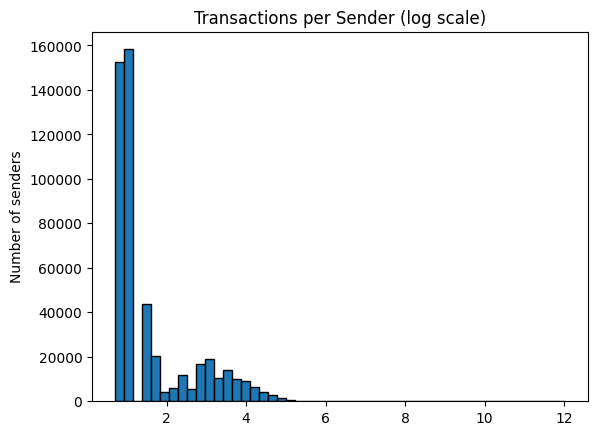

In [71]:
txn_per_account = aml_dataset.groupby('sender_id').size()
print(txn_per_account.describe())

plt.hist(np.log1p(txn_per_account), bins=50, edgecolor='black')
plt.title('Transactions per Sender (log scale)')
plt.ylabel('Number of senders')
plt.show()

This chart shows how active each account is, how many transactions each sender made over the period covered by the data. The chart uses a log scale which is a compressed scale to make both the low-activity majority and the high-activity minority visible in the same view. Without it, the handful of very active accounts would make the chart hard to read.

In [72]:
mismatch_rate = (aml_dataset['Payment Currency'] != aml_dataset['Receiving Currency']).mean()
print(f"Cross-currency transactions: {mismatch_rate * 100:.2f}%")
print(f"Unique sending banks: {aml_dataset['From Bank'].nunique()}")
print(f"Unique receiving banks: {aml_dataset['To Bank'].nunique()}")

Cross-currency transactions: 1.42%
Unique sending banks: 30470
Unique receiving banks: 15811


# Feature Engineering & Preprocessing

In [73]:
aml_dataset = aml_dataset.sort_values('Timestamp').reset_index(drop=True)

# Historical features: each transaction sees only the sender's prior transactions
aml_dataset['txn_count'] = aml_dataset.groupby('sender_id').cumcount()
aml_dataset['avg_amount'] = (
    aml_dataset.groupby('sender_id')['Amount Paid']
    .transform(lambda s: s.shift().expanding().mean())
)

# Time since this sender's previous transaction (in hours)
aml_dataset['time_since_last'] = (
    aml_dataset.groupby('sender_id')['Timestamp']
    .diff()
    .dt.total_seconds() / 3600
)

# How many times this sender has sent this exact amount before
aml_dataset['amount_repeat_count'] = (
    aml_dataset.groupby(['sender_id', 'Amount Paid']).cumcount()
)


# District counterparties seen before this transaction
first_seen = ~aml_dataset.duplicated(subset=['sender_id', 'receiver_id'])
aml_dataset['unique_counterparties'] = first_seen.groupby(aml_dataset['sender_id']).cumsum()
aml_dataset['unique_counterparties'] = aml_dataset.groupby('sender_id')['unique_counterparties'].shift()

In [74]:
# Transaction Level features
aml_dataset['log_amount'] = np.log1p(aml_dataset['Amount Paid'])
aml_dataset['amount_deviation'] = (aml_dataset['Amount Paid'] - aml_dataset['avg_amount']) / (aml_dataset['avg_amount'] + 1e-8)
aml_dataset['amount_deviation'] = aml_dataset['amount_deviation'].clip(-10, 10)
aml_dataset['currency_mismatch'] = (aml_dataset['Payment Currency'] != aml_dataset['Receiving Currency']).astype(int)

In [75]:
# Encode Payment Format
payment_dummies = pd.get_dummies(aml_dataset['Payment Format'], prefix='pay_fmt', drop_first=True)
aml_dataset = pd.concat([aml_dataset, payment_dummies], axis=1)

In [76]:
# Feature Matrix
feature_cols = [
    'log_amount', 'amount_deviation', 'txn_count', 'unique_counterparties',
    'currency_mismatch', 'time_since_last', 'amount_repeat_count'
] + [col for col in aml_dataset.columns if col.startswith('pay_fmt_')]

X = aml_dataset[feature_cols].copy()
print(X.shape)
print(X.isnull().sum())

(5078345, 13)
log_amount                    0
amount_deviation         496999
txn_count                     0
unique_counterparties    496999
currency_mismatch             0
time_since_last          496999
amount_repeat_count           0
pay_fmt_Bitcoin               0
pay_fmt_Cash                  0
pay_fmt_Cheque                0
pay_fmt_Credit Card           0
pay_fmt_Reinvestment          0
pay_fmt_Wire                  0
dtype: int64


In [77]:
# Preprocessing for Modeling
labels = aml_dataset['Is Laundering'].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modeling

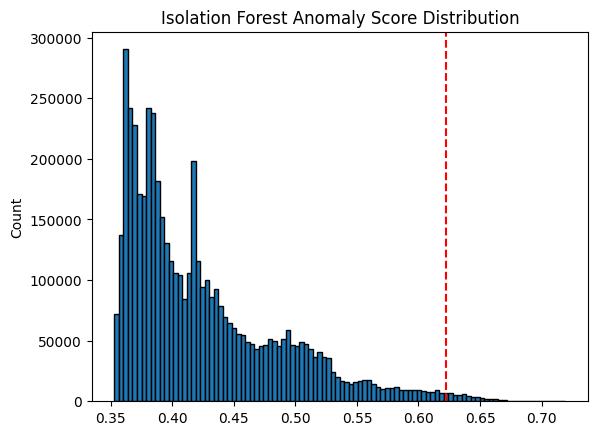

In [78]:
# Isolation Forest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)
iso_scores = -iso_forest.score_samples(X_scaled)

plt.hist(iso_scores, bins=100, edgecolor='black')
plt.axvline(np.percentile(iso_scores, 99), color='red', linestyle='--')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.ylabel('Count')
plt.show()

Most transactions score low, with a small tail of high-scoring transactions. The red line marks the 99th percentile, which is a natural starting point for a flagging threshold.

#### Autoencoder

In [79]:
# Defining the Network

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_tensor = torch.FloatTensor(X_scaled)

class TransactionAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim),
        )

    def forward(self, x):
      return self.decoder(self.encoder(x))

torch.manual_seed(42)
model = TransactionAutoencoder(input_dim=X_tensor.shape[1]).to(device)

Using device: cuda


In [80]:
# Training

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(42)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=4096, shuffle=True)

epochs = 20
train_losses = []

model.train()
for epoch in range(epochs):
  epoch_loss = 0
  for (x_batch,) in dataloader:
    x_batch = x_batch.to(device)
    reconstruction = model(x_batch)
    loss = criterion(reconstruction, x_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  avg_loss = epoch_loss / len(dataloader)
  train_losses.append(avg_loss)
  if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [5/20], Loss: 0.264071
Epoch [10/20], Loss: 0.199555
Epoch [15/20], Loss: 0.189280
Epoch [20/20], Loss: 0.187528


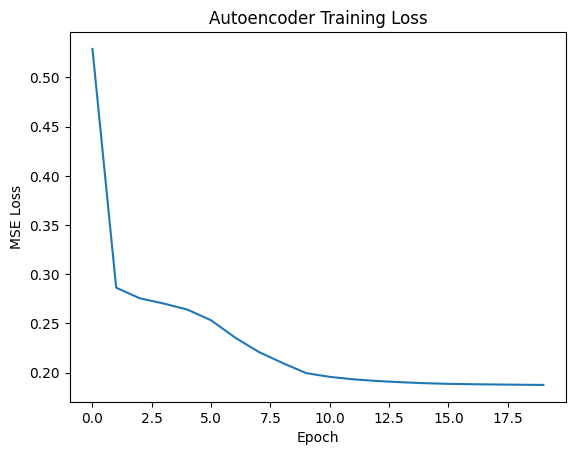

In [81]:
plt.plot(train_losses)
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

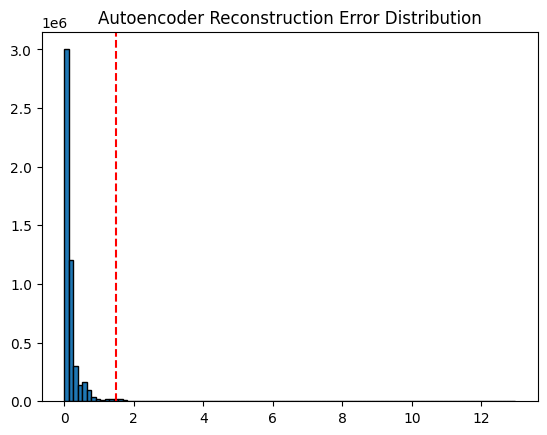

In [82]:
# Scoring

model.eval()
with torch.no_grad():
  X_dev = X_tensor.to(device)
  reconstruction = model(X_dev)
  ae_scores = torch.mean((X_dev - reconstruction) ** 2, dim=1).cpu().numpy()

plt.hist(ae_scores, bins=100, edgecolor='black')
plt.axvline(np.percentile(ae_scores, 99), color='red', linestyle='--')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.show()

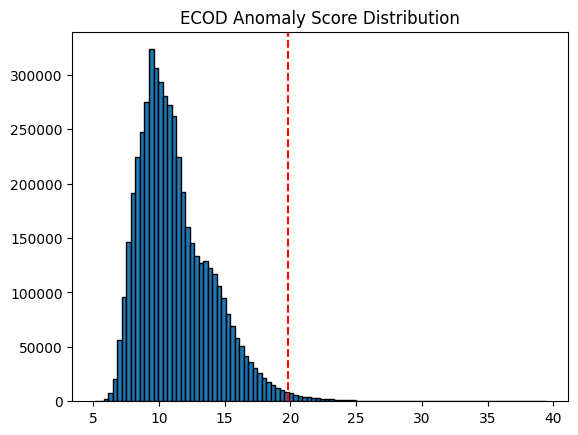

In [83]:
# ECOD

ecod = ECOD(contamination=0.01)
ecod.fit(X_scaled)
ecod_scores = ecod.decision_scores_

plt.hist(ecod_scores, bins=100, edgecolor='black')
plt.axvline(np.percentile(ecod_scores, 99), color='red', linestyle='--')
plt.title('ECOD Anomaly Score Distribution')
plt.show()

In [84]:
# Comparing the Three Models

def normalize_scores(scores):
  return MinMaxScaler().fit_transform(scores.reshape(-1, 1)).flatten()

iso_norm = normalize_scores(iso_scores)
ae_norm = normalize_scores(ae_scores)
ecod_norm = normalize_scores(ecod_scores)

combined_score = (iso_norm + ae_norm + ecod_norm) / 3

agreement = pd.DataFrame({
    'iso_score': iso_norm,
    'ae_score': ae_norm,
    'ecod_score': ecod_norm,
    'combined_score': combined_score
})
print(agreement.corr())

                iso_score  ae_score  ecod_score  combined_score
iso_score        1.000000  0.470836    0.857568        0.981732
ae_score         0.470836  1.000000    0.467667        0.546426
ecod_score       0.857568  0.467667    1.000000        0.932638
combined_score   0.981732  0.546426    0.932638        1.000000


Isolation Forest and ECOD agreed with each other quite a bit (a correlation of 0.86), while the autoencoder stood out as the odd one out, agreeing with the other two only moderately (around 0.46-0.47). This actually makes sense when I think about how each method works: Isolation Forest and ECOD both flag transactions that sit in sparse or extreme parts of the data, just measured in different ways, so it's not surprising they end up circling the same suspicious transactions.

The autoencoder, on the other hand, is looking for something different: transactions it struggles to reconstruct based on the patterns it learned, which means it's catching cases the other two might miss.

# Post Hoc Validation

In [85]:
results = aml_dataset[['sender_id', 'receiver_id', 'Amount Paid', 'Payment Format']].copy()
results['iso_score'] = iso_norm
results['ae_score'] = ae_norm
results['ecod_score'] = ecod_norm
results['combined_score'] = combined_score
results['is_laundering'] = labels.values

results.sort_values('combined_score', ascending=False).head(10)

,sender_id,receiver_id,Amount Paid,Payment Format,iso_score,ae_score,ecod_score,combined_score,is_laundering
5070466,70_100428660,28694_813BB7490,31.48,Cheque,0.783400,1.000000,0.982035,0.921812,0
4997750,70_100428660,110836_8093625D0,31.48,Credit Card,0.844285,0.945527,0.906684,0.898832,0
4899399,70_100428660,21575_80D2FBB80,31.48,Cheque,0.782218,0.890767,0.856855,0.843280,0
4712539,70_100428660,110836_8093625D0,31.48,Credit Card,0.841841,0.843131,0.843781,0.842917,0
4697428,70_100428660,123997_810749880,31.48,Cash,0.867525,0.791841,0.865605,0.841657,0
4995983,70_100428660,11157_801A90FF0,37.29,Credit Card,0.859022,0.804686,0.855601,0.839770,0
5066293,70_100428660,23885_8019EF3E0,10.06,Credit Card,0.846733,0.671884,0.948361,0.822326,0
4643411,70_100428660,12979_807CEBAF0,31.48,Cash,0.867525,0.702075,0.846947,0.805516,0
4936879,70_100428660,28827_809B979F0,37.29,Credit Card,0.843062,0.715058,0.837482,0.798534,0
4892549,70_100428660,3149_8032FADC0,37.29,Cash,0.884952,0.665618,0.843952,0.798174,0


In [86]:
# Precision at K

label_array = labels.values
baseline = label_array.mean()
print(f"Laundering rate: {baseline * 100:.2f}%")

def precision_at_k(scores, labels, k):
  top_k_idx = np.argsort(scores)[::-1][:k]
  return labels[top_k_idx].mean()

methods = {
    'Combined': combined_score,
    'Isolation Forest': iso_norm,
    'Autoencoder': ae_norm,
    'ECOD': ecod_norm
}

for k in [100, 500, 1000, 2000]:
  print(f"\nTop {k}:")
  for name, scores in methods.items():
    p = precision_at_k(scores, label_array, k)
    print(f" {name:18s} Precision={p:.4f} | Lift={p/baseline:.2f}x")

Laundering rate: 0.10%

Top 100:
 Combined           Precision=0.0000 | Lift=0.00x
 Isolation Forest   Precision=0.0000 | Lift=0.00x
 Autoencoder        Precision=0.0900 | Lift=88.28x
 ECOD               Precision=0.0100 | Lift=9.81x

Top 500:
 Combined           Precision=0.0040 | Lift=3.92x
 Isolation Forest   Precision=0.0020 | Lift=1.96x
 Autoencoder        Precision=0.0820 | Lift=80.44x
 ECOD               Precision=0.0020 | Lift=1.96x

Top 1000:
 Combined           Precision=0.0020 | Lift=1.96x
 Isolation Forest   Precision=0.0010 | Lift=0.98x
 Autoencoder        Precision=0.0610 | Lift=59.84x
 ECOD               Precision=0.0020 | Lift=1.96x

Top 2000:
 Combined           Precision=0.0020 | Lift=1.96x
 Isolation Forest   Precision=0.0005 | Lift=0.49x
 Autoencoder        Precision=0.0415 | Lift=40.71x
 ECOD               Precision=0.0025 | Lift=2.45x


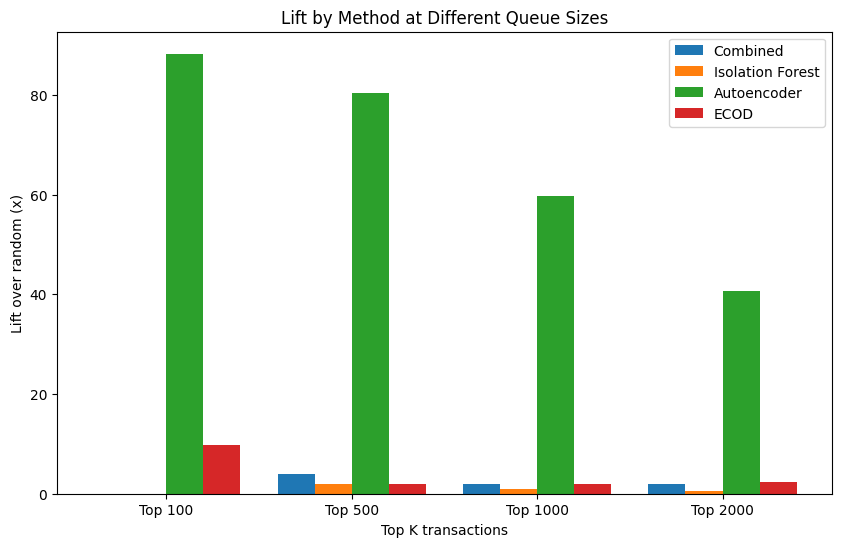

In [87]:
import matplotlib.pyplot as plt

k_values = [100, 500, 1000, 2000]
methods = {
    'Combined': combined_score,
    'Isolation Forest': iso_norm,
    'Autoencoder': ae_norm,
    'ECOD': ecod_norm
}

# Calculate lift for each method at each K
lift_data = {name: [precision_at_k(scores, label_array, k) / baseline for k in k_values]
             for name, scores in methods.items()}

# Grouped bar chart
x = np.arange(len(k_values))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, lifts) in enumerate(lift_data.items()):
    ax.bar(x + i * width, lifts, width, label=name)

ax.set_xlabel('Top K transactions')
ax.set_ylabel('Lift over random (x)')
ax.set_title('Lift by Method at Different Queue Sizes')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Top {k}' for k in k_values])
ax.legend()
plt.show()

In [89]:
# ROC-AUC

print(f"Combined ROC-AUC: {roc_auc_score(label_array, combined_score):.4f}")
print(f"Isolation Forest ROC-AUC: {roc_auc_score(label_array, iso_norm):.4f}")
print(f"Autoencoder ROC-AUC: {roc_auc_score(label_array, ae_norm):.4f}")
print(f"ECOD ROC-AUC: {roc_auc_score(label_array, ecod_norm):.4f}")

Combined ROC-AUC: 0.5015
Isolation Forest ROC-AUC: 0.4448
Autoencoder ROC-AUC: 0.7782
ECOD ROC-AUC: 0.5458


In [90]:
# PR-AUC

print(f"Combined PR-AUC: {average_precision_score(label_array, combined_score):.4f}")
print(f"Isolation Forest PR-AUC: {average_precision_score(label_array, iso_norm):.4f}")
print(f"Autoencoder PR-AUC: {average_precision_score(label_array, ae_norm):.4f}")
print(f"ECOD PR-AUC: {average_precision_score(label_array, ecod_norm):.4f}")

Combined PR-AUC: 0.0013
Isolation Forest PR-AUC: 0.0010
Autoencoder PR-AUC: 0.0046
ECOD PR-AUC: 0.0013


When I reviewed the three detection methods individually, the Autoencoder clearly stood out. It showed far more laundering at the top of the queue than Isolation Forest or ECOD, which contributed little useful signal. Combining all three into a single score produced a weaker result than using the Autoencoder alone, because the two weaker methods diluted the strong signal rather than reinforcing it. Combining multiple detection methods doesn't automatically produce a better result than the best method alone, and each method should be evaluated individually before assuming a combined score is the right choice.

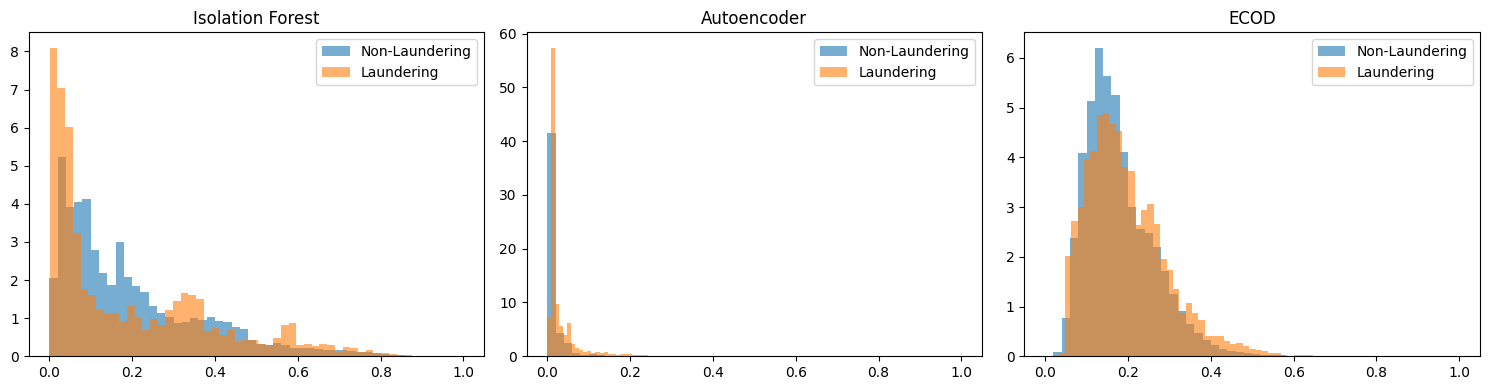

In [91]:
# Score Distribution by Label

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, scores) in zip(axes, [('Isolation Forest', iso_norm),
                                     ('Autoencoder', ae_norm),
                                     ('ECOD', ecod_norm)]):
  ax.hist(scores[label_array == 0], bins=50, alpha=0.6, label='Non-Laundering', density=True)
  ax.hist(scores[label_array == 1], bins=50, alpha=0.6, label='Laundering', density=True)
  ax.set_title(name)
  ax.legend()
plt.tight_layout()
plt.show()

In [92]:
# Investigation Queue

results['combined_score'] = combined_score

investigation_queue = results.sort_values('combined_score', ascending=False).head(500)
print(f"Known laundering captured: {investigation_queue['is_laundering'].sum()} / 500")
print(f"Precision: {investigation_queue['is_laundering'].mean():.4f}")

Known laundering captured: 2 / 500
Precision: 0.0040


The combined score blends all three detection methods into a single ranking. Among its 500 highest-priority transactions, 2 are actual laundering cases which is barely above what random review would surface, and far below the Autoencoder on its own. Averaging the three methods let the two weaker ones dominate and pulled the result down toward noise.

In [93]:
top500_ae = results.sort_values('ae_score', ascending=False).head(500)
print(f"Known laundering captured (Autoencoder only): {top500_ae['is_laundering'].sum()} / 500")
print(f"Precision: {top500_ae['is_laundering'].mean():.4f}")

Known laundering captured (Autoencoder only): 41 / 500
Precision: 0.0820


Among the 500 highest-priority transactions the system flags, 41 are actual laundering cases when using autoencoder. Because laundering is rare here (about 1 in 1,000 transactions), reviewing 500 at random would surface only about one. The system's queue is therefore roughly 80 times more concentrated with laundering than random review, which is a meaningful head start for a team deciding where to focus limited investigative time.

This single method outperformed the combined three-method ensemble, which captured just 2 cases in the same top 500; the two weaker methods diluted the result rather than strengthening it.

This answers the original business question directly: unsupervised methods can surface suspicious transactions worth investigating, without relying on labeled data.